In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sgp4.api import accelerated
from datetime import datetime, timedelta
import requests
import os
from dotenv import load_dotenv

In [2]:
print(accelerated)

True


In [3]:
tle_data = []

In [4]:
load_dotenv()
url = os.getenv ("tle_url")
page = requests.get(url)
content = page.json()["data"]["tles"]

for i in content:
    name = i.get('name')
    firstLine = i.get('firstLine')
    secondLine = i.get('secondLine')
    tle_data.append((name, firstLine, secondLine))

In [5]:
print(f"Fetched {len(tle_data)} TLE entries.")

Fetched 27766 TLE entries.


In [6]:
import pandas as pd

df = pd.DataFrame(tle_data, columns=['name', 'firstLine', 'secondLine'])
print(df.head(15))

                      name                                          firstLine  \
0               VANGUARD 2  1    11U 59001A   25320.77762426  .00000911  0...   
1             VANGUARD R/B  1 00012U 59001B   25320.11740857  .00002051  0...   
2               VANGUARD 3  1 00020U 59007A   25319.98927369  .00003501  0...   
3               EXPLORER 7  1    22U 59009A   25320.73838818  .00015190  0...   
4                  TIROS 1  1    29U 60002B   25320.67052459  .00001534  0...   
5               TRANSIT 2A  1 00045U 60007A   25320.64611562  .00000776  0...   
6          SOLRAD 1 (GREB)  1 00046U 60007B   25320.46270125  .00001893  0...   
7        THOR ABLESTAR R/B  1    47U 60007C   25320.78562072  .00001444  0...   
8              DELTA 1 R/B  1    50U 60009B   25320.67061669 -.00000092  0...   
9   ECHO 1 DEB (METAL OBJ)  1 00051U 60009C   25320.35716066 -.00000058  0...   
10  ECHO 1 DEB (METAL OBJ)  1    53U 60009E   25320.63020229 -.00000056  0...   
11              COURIER 1B  

In [7]:
for name, firstline, secondline in tle_data[:15]:
    print(f"name: {name}\nfirstLine: {firstline}\nsecondLine: {secondline}\n")

name: VANGUARD 2
firstLine: 1    11U 59001A   25320.77762426  .00000911  00000-0  45944-3 0  9990
secondLine: 2    11  32.8737 168.8410 1448574 288.3857  56.4870 11.90122260510152

name: VANGUARD R/B
firstLine: 1 00012U 59001B   25320.11740857  .00002051  00000-0  12062-2 0  9994
secondLine: 2 00012  32.8972 256.1173 1647499  56.8656 317.9377 11.48310332506821

name: VANGUARD 3
firstLine: 1 00020U 59007A   25319.98927369  .00003501  00000-0  14033-2 0  9998
secondLine: 2 00020  33.3461 314.4032 1639693 350.8251   6.5516 11.61472151459811

name: EXPLORER 7
firstLine: 1    22U 59009A   25320.73838818  .00015190  00000-0  58585-3 0  9995
secondLine: 2    22  50.2690  66.3609 0086430 349.4967  10.4183 15.23024885767905

name: TIROS 1
firstLine: 1    29U 60002B   25320.67052459  .00001534  00000-0  23687-3 0  9991
secondLine: 2    29  48.3790 314.3361 0021878  72.6143 287.7161 14.78349719510689

name: TRANSIT 2A
firstLine: 1 00045U 60007A   25320.64611562  .00000776  00000-0  21135-3 0  999

In [8]:
head_15 =  tle_data[:15] # Store the first 15 TLE entries in a variable

In [9]:
for name, firstline, secondline in head_15:
    print(f"name: {name}\nfirstLine: {firstline}\nsecondLine: {secondline}\n")

name: VANGUARD 2
firstLine: 1    11U 59001A   25320.77762426  .00000911  00000-0  45944-3 0  9990
secondLine: 2    11  32.8737 168.8410 1448574 288.3857  56.4870 11.90122260510152

name: VANGUARD R/B
firstLine: 1 00012U 59001B   25320.11740857  .00002051  00000-0  12062-2 0  9994
secondLine: 2 00012  32.8972 256.1173 1647499  56.8656 317.9377 11.48310332506821

name: VANGUARD 3
firstLine: 1 00020U 59007A   25319.98927369  .00003501  00000-0  14033-2 0  9998
secondLine: 2 00020  33.3461 314.4032 1639693 350.8251   6.5516 11.61472151459811

name: EXPLORER 7
firstLine: 1    22U 59009A   25320.73838818  .00015190  00000-0  58585-3 0  9995
secondLine: 2    22  50.2690  66.3609 0086430 349.4967  10.4183 15.23024885767905

name: TIROS 1
firstLine: 1    29U 60002B   25320.67052459  .00001534  00000-0  23687-3 0  9991
secondLine: 2    29  48.3790 314.3361 0021878  72.6143 287.7161 14.78349719510689

name: TRANSIT 2A
firstLine: 1 00045U 60007A   25320.64611562  .00000776  00000-0  21135-3 0  999

In [10]:
from sgp4.api import Satrec

satellites_satrec = [] #contains the satellite name and its satrec object

for name, firstline, secondline in head_15:
    sat = Satrec.twoline2rv(firstline, secondline)
    satellites_satrec.append((name, sat))

In [11]:
#for testing actually:

# The Satrec object has the epoch stored:
print(sat.epochyr)   # Year (e.g., 2025)
print(sat.epochdays) # Day of year with fraction (e.g., 316.83333976)
print(sat.jdsatepoch) # Julian date of epoch

25
320.69647726
2460995.5


In [12]:
for name, sat in satellites_satrec:
    print(f"""Satelite Name :{name}
          Satrec Epoch Year: {sat.epochyr} 
          Satrec Epoch Day: {sat.epochdays} 
          Satrec Julian Date: {sat.jdsatepoch}""")

Satelite Name :VANGUARD 2
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 320.77762426 
          Satrec Julian Date: 2460995.5
Satelite Name :VANGUARD R/B
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 320.11740857 
          Satrec Julian Date: 2460995.5
Satelite Name :VANGUARD 3
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 319.98927369 
          Satrec Julian Date: 2460994.5
Satelite Name :EXPLORER 7
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 320.73838818 
          Satrec Julian Date: 2460995.5
Satelite Name :TIROS 1
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 320.67052459 
          Satrec Julian Date: 2460995.5
Satelite Name :TRANSIT 2A
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 320.64611562 
          Satrec Julian Date: 2460995.5
Satelite Name :SOLRAD 1 (GREB)
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 320.46270125 
          Satrec Julian Date: 2460995.5
Satelite 

In [ ]:
from sgp4.api import jday

start_time = datetime.now()
end_time = start_time + timedelta(hours=1)
time_stamp = 60 # seconds
time_stamps = []

current_time = start_time

time_stamped_positions = {}

while current_time <= end_time:
    time_stamps.append(current_time)
    current_time += timedelta(seconds=30)

# Now compute positions and velocities for each satellite at each time stamp
for name, sat in satellites_satrec:
    for time_point in time_stamps:
        jd, fr = jday(time_point.year, time_point.month, time_point.day,
                      time_point.hour, time_point.minute, time_point.second + time_point.microsecond * 1e-6)
        e, r, v = sat.sgp4(jd, fr)
        time_stamped_positions.setdefault(name, []).append((time_point, r, v))

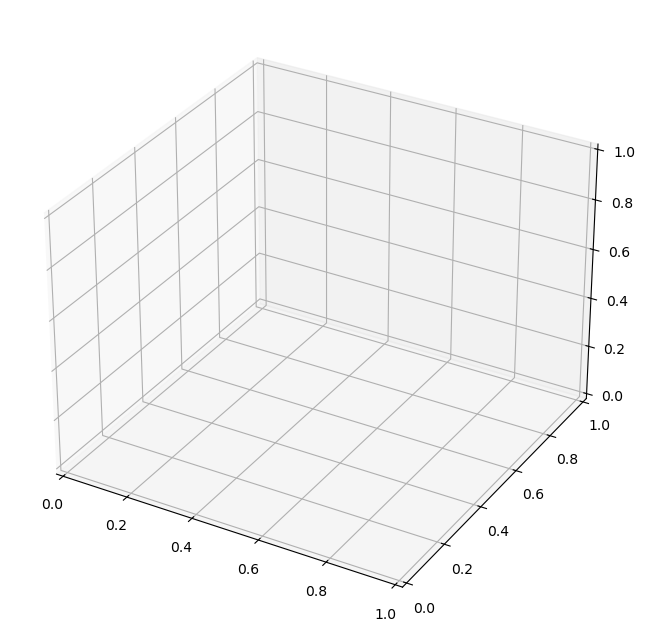

In [15]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

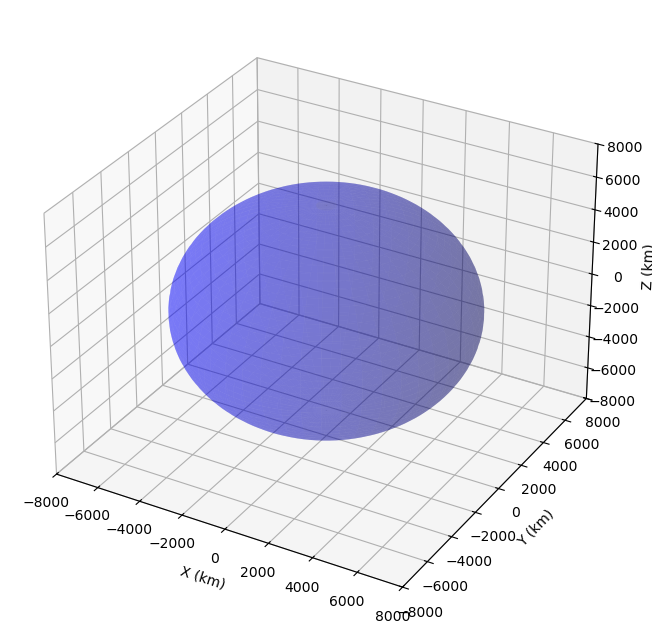

In [16]:
#plotting the earth - 

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim([-8000, 8000])
ax.set_ylim([-8000, 8000])
ax.set_zlim([-8000, 8000])
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)
x = 6371 * np.outer(np.cos(u), np.sin(v))
y = 6371 * np.outer(np.sin(u), np.sin(v))
z = 6371 * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x, y, z, color='b', alpha=0.3)

<function matplotlib.pyplot.show(close=None, block=None)>

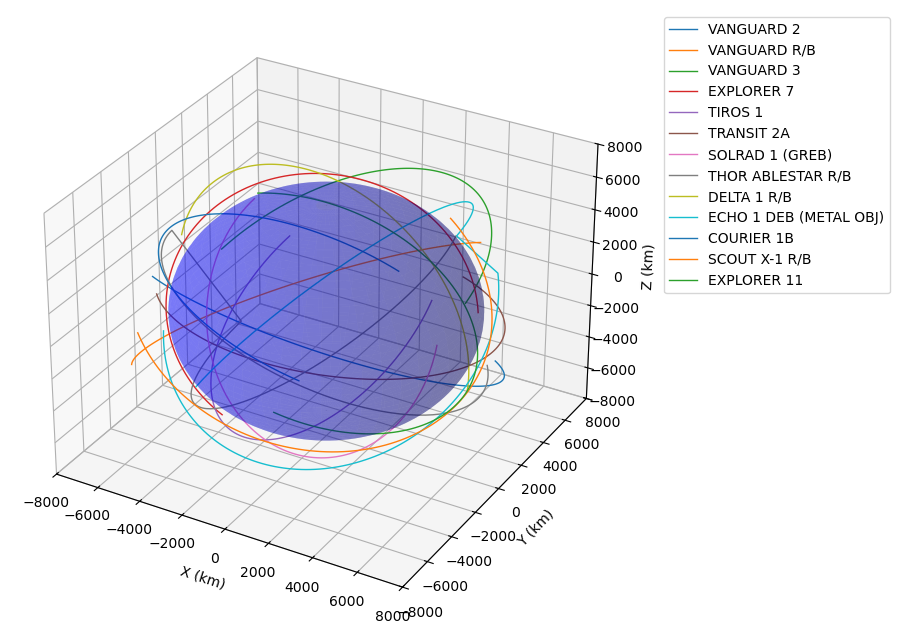

In [17]:
#plotting through each satelites;

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_xlim([-8000, 8000])
ax.set_ylim([-8000, 8000])
ax.set_zlim([-8000, 8000])
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_zlabel('Z (km)')

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)
x = 6371 * np.outer(np.cos(u), np.sin(v))
y = 6371 * np.outer(np.sin(u), np.sin(v))
z = 6371 * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x, y, z, color='b', alpha=0.3)

for name, positions in time_stamped_positions.items():
    xs = [r[0] for time_point, r, v in positions]
    ys = [r[1] for time_point, r, v in positions]
    zs = [r[2] for time_point, r, v in positions]
    
    ax.plot(xs, ys, zs, label=name, linewidth=1)

ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.show